# A2Q2

## Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm 
import numpy as np
import math

# Helper Functions

### Calculating Accuracy

In [52]:
def get_accuracy(data_loader, device, model) -> float:
    """Calculates the accuracy of a model on a dataset

    Args:
        data_loader: The data loader for a dataset
        device: Set to "cuda" for GPU acceleration
        model: The model to get the accuracy of

    Returns:
        float: the accuracy of the model as a percentage [0, 100]
    """
     
    # get accuracy for each batch in test set with horizontal flip
    correct = 0
    total = 0
    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)
        # get prediction results
        outputs = model(images)

        # calculate accuracy
        with torch.no_grad():
            _, predicted = torch.max(outputs, 1) 
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total * 100

## Setting up CUDA for GPU acceleration

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Downloading the MNIST dataset

In [19]:
BATCH_SIZE=256

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Creating the CNN architecture

Implements the VGG11 Network

In [20]:
class VGG11(nn.Module):
    """Implements VGG11 (at home)

    Args:
        nn.Module: Base NN class from pytorch
    """

    def __init__(self):
        """Intializes all the layers of the CNN
        
        """
        super(VGG11, self).__init__()

        # convolutional layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.conv5 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(512)

        self.conv6 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(512)

        self.conv7 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.bn7 = nn.BatchNorm2d(512)

        self.conv8 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.bn8 = nn.BatchNorm2d(512)

        # pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # fully connected layers
        self.fc1 = nn.Linear(512, 4096)
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, 10)

        # dropout
        self.dropout = nn.Dropout(p=0.5)

        # activation function 
        self.relu = nn.ReLU()

    def forward(self, x):
        """Implements the forward step for the CNN

        Args:
            x : input data
        """
        # Conv1 -> BN -> ReLU -> Pool
        x = self.pool(self.relu(self.bn1(self.conv1(x)))) 
        # Conv2 -> BN -> ReLU -> Pool
        x = self.pool(self.relu(self.bn2(self.conv2(x)))) 
        # Conv3 -> BN -> ReLU
        x = self.relu(self.bn3(self.conv3(x)))
        # Conv4 -> BN -> ReLU -> Pool
        x = self.pool(self.relu(self.bn4(self.conv4(x)))) 
        # Conv5 -> BN -> ReLU
        x = self.relu(self.bn5(self.conv5(x)))
        # Conv6 -> BN -> ReLU -> Pool
        x = self.pool(self.relu(self.bn6(self.conv6(x)))) 
        # Conv7 -> BN -> ReLU
        x = self.relu(self.bn7(self.conv7(x)))
        # Conv8 -> BN -> ReLU -> Pool
        x = self.pool(self.relu(self.bn8(self.conv8(x)))) 

        # flatten before passing to FC layers
        x = x.view(x.size(0), -1)

        # FC1 -> ReLu -> Dropout
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        # FC2 -> ReLu -> Dropout
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        # FC3 -> ReLu
        x = self.relu(self.fc3(x))

        return x

## Training the CNN

In [21]:
# average loss across all mini-batches
train_loss = []
train_accuracy = []

test_loss = []
test_accuracy = []

model = VGG11().to(device)
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
# the parametes to match the paper
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=5e-4, betas=(0.9, 0.999))
# define learning rate scheduler, supposed to be used with validation set, but I dont have on  
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, min_lr=1e-6)

# Training loop
num_epochs = 80
for epoch in tqdm(range(num_epochs), position=0, leave=False):
    running_loss = 0.0
    correct = 0
    total = 0
    # gradient descent 
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        # zero gradients for gradient descent
        optimizer.zero_grad()
        # get prediction results
        outputs = model(images)
        # calculate loss
        loss = criterion(outputs, labels)
        loss.backward()
        # updates weights
        optimizer.step()

        # add loss history
        running_loss += loss.item()

        # calculate accuracy
        with torch.no_grad():
            _, predicted = torch.max(outputs, 1) 
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    train_loss.append(running_loss / len(train_loader))
    train_accuracy.append(100 * correct / total)
    scheduler.step(train_loss[-1])

    # get loss and accuracy for each batch in test set for graphing in part b
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        # get prediction results
        outputs = model(images)
        # calculate loss
        loss = criterion(outputs, labels)

        # add loss history
        running_loss += loss.item()

        # calculate accuracy
        with torch.no_grad():
            _, predicted = torch.max(outputs, 1) 
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    test_loss.append(running_loss / len(test_loader))
    test_accuracy.append(100 * correct / total)

    tqdm.write(f"Epoch {epoch+1}: LR: {scheduler.get_last_lr()[0]}, Training Loss = {train_loss[-1]:.4f}, Training Accuracy = {train_accuracy[-1]:.2f}%")

  1%|▏         | 1/80 [00:05<07:37,  5.79s/it]

Epoch 1: LR: 0.001, Training Loss = 2.3082, Training Accuracy = 9.85%


  2%|▎         | 2/80 [00:11<07:29,  5.76s/it]

Epoch 2: LR: 0.001, Training Loss = 2.3026, Training Accuracy = 9.87%


  4%|▍         | 3/80 [00:17<07:23,  5.75s/it]

...

 98%|█████████▊| 78/80 [07:27<00:11,  5.74s/it]

Epoch 78: LR: 0.0001, Training Loss = 0.0017, Training Accuracy = 99.99%


 99%|█████████▉| 79/80 [07:33<00:05,  5.74s/it]

Epoch 79: LR: 0.0001, Training Loss = 0.0015, Training Accuracy = 99.99%


Epoch 80: LR: 0.0001, Training Loss = 0.0015, Training Accuracy = 99.99%


### Test Accuracy vs Num Epochs

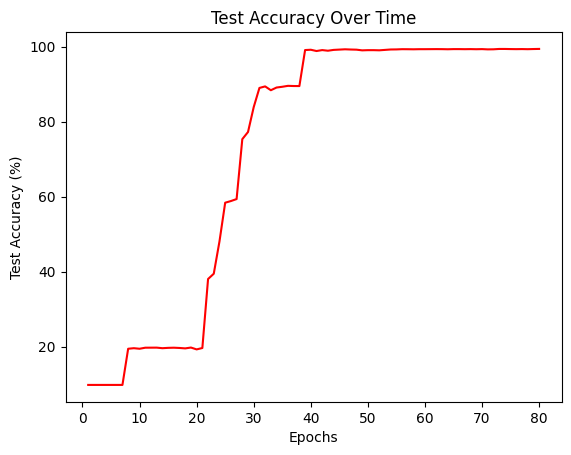

In [24]:
epochs = np.arange(1, 81) 
plt.plot(epochs, test_accuracy, linestyle='-', color='r')

# Add labels and title
plt.xlabel("Epochs")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Over Time")

# Show the graph
plt.show()
plt.close()

### Training Accuracy vs Epochs

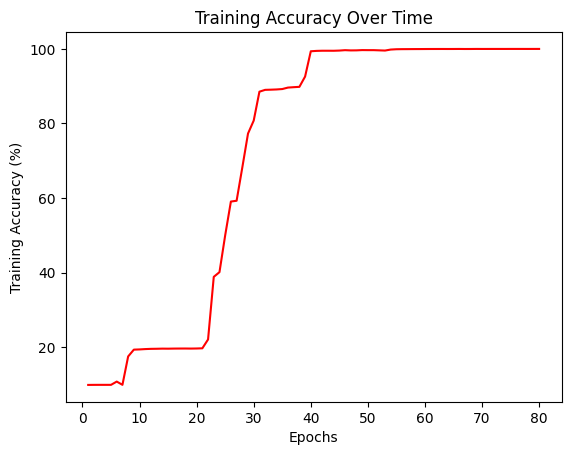

In [25]:
plt.plot(epochs, train_accuracy, linestyle='-', color='r')

# Add labels and title
plt.xlabel("Epochs")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Accuracy Over Time")

# Show the graph
plt.show()
plt.close()

### Test Loss vs Epochs

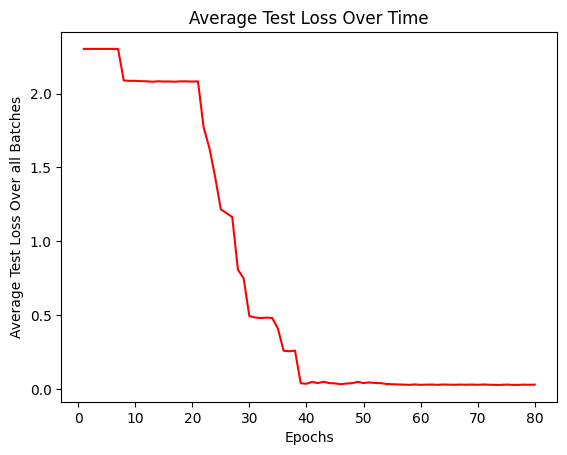

In [27]:
plt.plot(epochs, test_loss, linestyle='-', color='r')

# Add labels and title
plt.xlabel("Epochs")
plt.ylabel("Average Test Loss Over all Batches")
plt.title("Average Test Loss Over Time")

# Show the graph
plt.show()
plt.close()

### Training Loss vs Epochs

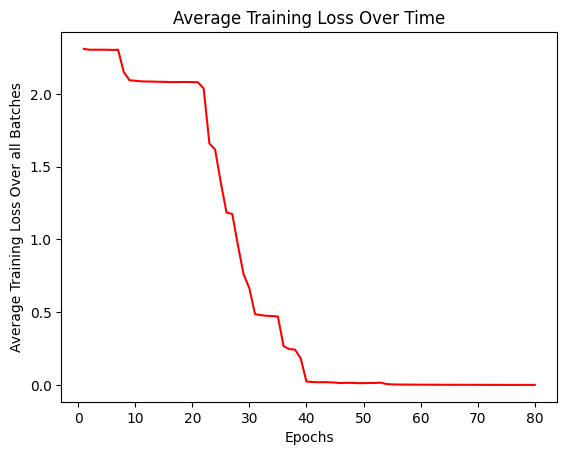

In [28]:
plt.plot(epochs, train_loss, linestyle='-', color='r')

# Add labels and title
plt.xlabel("Epochs")
plt.ylabel("Average Training Loss Over all Batches")
plt.title("Average Training Loss Over Time")

# Show the graph
plt.show()
plt.close()

## Testing with Augmented Data

### Horizontal Flip

In [64]:
# create transformer to flip input data
horizontal_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(p=1),
    transforms.ToTensor()
])

# load the new test set
test_dataset_horizontal = torchvision.datasets.MNIST(root='./data', train=False, transform=horizontal_transform, download=True)
test_loader_horizontal = DataLoader(test_dataset_horizontal, batch_size=BATCH_SIZE, shuffle=False)

horizontal_flip_accuracy = get_accuracy(test_loader_horizontal, device, model)
print(f"Accuracy with Horizontal Flips: {horizontal_flip_accuracy:.2f}%")

Accuracy with Horizontal Flips: 39.53%


### Vertical Flip

In [65]:
# create transformer to flip input data
vertical_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomVerticalFlip(p=1),
    transforms.ToTensor()
])

# load the new test set
test_dataset_vertical = torchvision.datasets.MNIST(root='./data', train=False, transform=vertical_transform, download=True)
test_loader_vertical = DataLoader(test_dataset_vertical, batch_size=BATCH_SIZE, shuffle=False)

vertical_flip_accuracy = get_accuracy(test_loader_vertical, device, model)
print(f"Accuracy with Vertical Flips: {vertical_flip_accuracy:.2f}%")

Accuracy with Vertical Flips: 43.60%


### Observations

We see that after augmenting the data, the model performs drastically worse. For a baseline, the trained model had an accuracy of 99.99% on the non-augmented data. After augmenting the data with a horizontal flip, the accuracy fell to 39.53%. The model preformed slightly better on the data that has been flipped vertically -- probably because more numbers look the same when flipped vertically than horizontally -- with an accuracy of 43.60%.

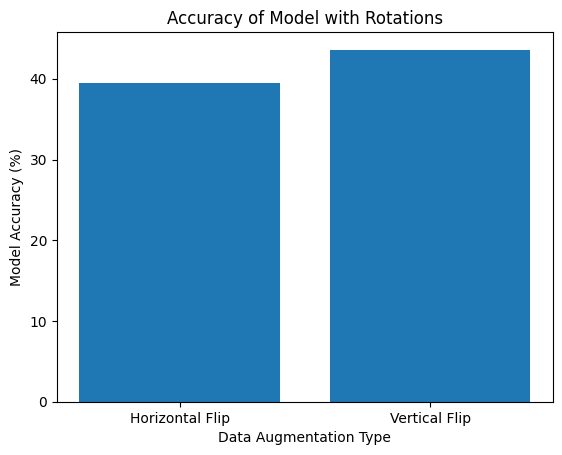

In [85]:
categories = ["Horizontal Flip", "Vertical Flip"]
vals= [horizontal_flip_accuracy, vertical_flip_accuracy]

# Create bar graph
plt.bar(categories, vals)

# Add labels and title
plt.xlabel("Data Augmentation Type")
plt.ylabel("Model Accuracy (%)")
plt.title("Accuracy of Model with Rotations")

plt.show()
plt.close()

### Gaussian Noise

We see that adding noise decreases the overall accuracy. We also see that as the variance gets larger the model performs much worse. For instance, when the variance is 0.01, the model accuracy only slightly degraded to 99.02% (compared to a baseline of 99.99%). However, when the variance is set to 1, the accuracy dramatically falls off to 25.23%. 

Accuracy with Gaussian Noise with Variance 0.01: 99.02%
Accuracy with Gaussian Noise with Variance 0.1: 89.18%
Accuracy with Gaussian Noise with Variance 1: 25.23%


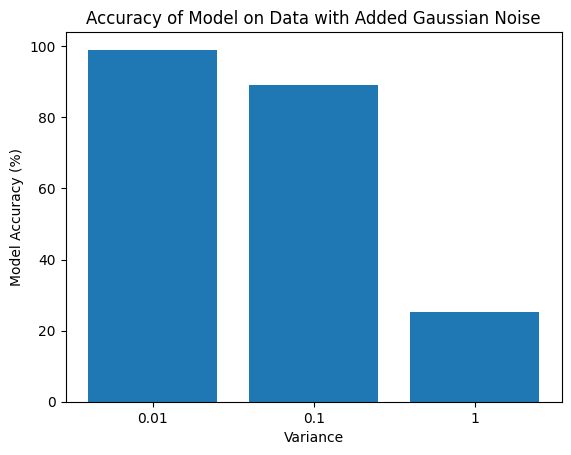

In [88]:
variances = ["0.01", "0.1", "1"]
gaussian_test_accuracies = []

for variance in variances:
    # create transformer with 0.01 var
    gaussian_transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x + math.sqrt(float(variance)) * torch.randn_like(x))
    ])

    test_dataset_gaussian = torchvision.datasets.MNIST(root='./data', train=False, transform=gaussian_transform, download=True)
    test_loader_gaussian = DataLoader(test_dataset_gaussian, batch_size=BATCH_SIZE, shuffle=False)

    gaussian_test_accuracies.append(get_accuracy(test_loader_gaussian, device, model))
    print(f"Accuracy with Gaussian Noise with Variance {variance}: {gaussian_test_accuracies[-1]:.2f}%")

# create bar plot
plt.bar(variances, gaussian_test_accuracies)

# Add labels and title
plt.xlabel("Variance")
plt.ylabel("Model Accuracy (%)")
plt.title("Accuracy of Model on Data with Added Gaussian Noise")

plt.show()
plt.close()


## Retraining with Horizontal and Vertical Flips, and Gaussian Noise

- The probability of each image being flipped horizontally is 50%
- The probability of each image being flipped vertically is 50%
- The variance of the applied Gaussian noise is 0.1

In [82]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x + math.sqrt(0.1) * torch.randn_like(x))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# average loss across all mini-batches
train_loss = []
train_accuracy = []

augmented_model = VGG11().to(device)
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
# the parametes to match the paper
optimizer = optim.Adam(augmented_model.parameters(), lr=learning_rate, weight_decay=5e-4, betas=(0.9, 0.999))
# define learning rate scheduler, supposed to be used with validation set, but I dont have on  
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10, min_lr=1e-6)

# Training loop
num_epochs = 100
for epoch in tqdm(range(num_epochs)):
    running_loss = 0.0
    correct = 0
    total = 0
    # gradient descent 
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        # zero gradients for gradient descent
        optimizer.zero_grad()
        # get prediction results
        outputs = augmented_model(images)
        # calculate loss
        loss = criterion(outputs, labels)
        loss.backward()
        # updates weights
        optimizer.step()

        # add loss history
        running_loss += loss.item()

        # calculate accuracy
        with torch.no_grad():
            _, predicted = torch.max(outputs, 1) 
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    train_loss.append(running_loss / len(train_loader))
    train_accuracy.append(100 * correct / total)
    scheduler.step(train_loss[-1])
    tqdm.write(f"Epoch {epoch+1}: LR: {scheduler.get_last_lr()[0]}, Training Loss = {train_loss[-1]:.4f}, Training Accuracy = {train_accuracy[-1]:.2f}%")

  1%|          | 1/100 [00:07<12:02,  7.30s/it]

Epoch 1: LR: 0.001, Training Loss = 2.3216, Training Accuracy = 9.94%


  2%|▏         | 2/100 [00:14<11:50,  7.25s/it]

Epoch 2: LR: 0.001, Training Loss = 2.3026, Training Accuracy = 9.87%


  3%|▎         | 3/100 [00:21<11:41,  7.23s/it]

...

Epoch 98: LR: 0.0001, Training Loss = 0.0446, Training Accuracy = 98.64%


 99%|█████████▉| 99/100 [11:54<00:07,  7.21s/it]

Epoch 99: LR: 0.0001, Training Loss = 0.0392, Training Accuracy = 98.81%


100%|██████████| 100/100 [12:01<00:00,  7.21s/it]

Epoch 100: LR: 0.0001, Training Loss = 0.0412, Training Accuracy = 98.80%


### Recalculating Horizontal and Vertical Flip Accuracy

Accuracy with Horizontal Flips: 98.03%
Accuracy with Vertical Flips: 97.66%


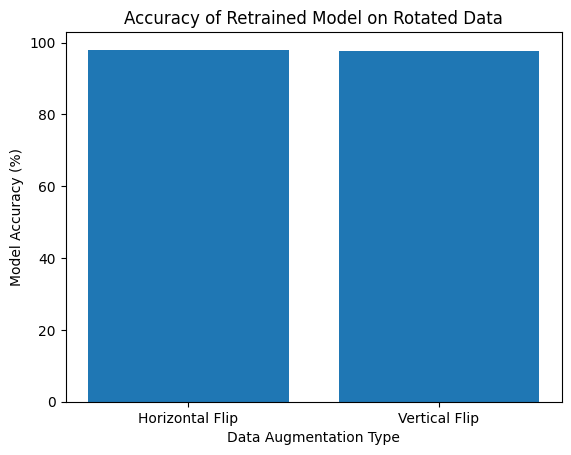

In [90]:
transform_arr = [horizontal_transform, vertical_transform]
flip_accuracies = []

for transform in transform_arr:
    # load the new test set
    test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    flip_accuracies.append(get_accuracy(test_loader, device, augmented_model))

print(f"Accuracy with Horizontal Flips: {flip_accuracies[0]:.2f}%")
print(f"Accuracy with Vertical Flips: {flip_accuracies[1]:.2f}%")

# create bar plot
plt.bar(["Horizontal Flip", "Vertical Flip"], flip_accuracies)

# Add labels and title
plt.xlabel("Data Augmentation Type")
plt.ylabel("Model Accuracy (%)")
plt.title("Accuracy of Retrained Model on Rotated Data")

plt.show()
plt.close()

### Recalculating Gaussian Noise Accuracy

Accuracy with Gaussian Noise with Variance 0.01: 97.64%
Accuracy with Gaussian Noise with Variance 0.1: 97.05%
Accuracy with Gaussian Noise with Variance 1: 58.43%


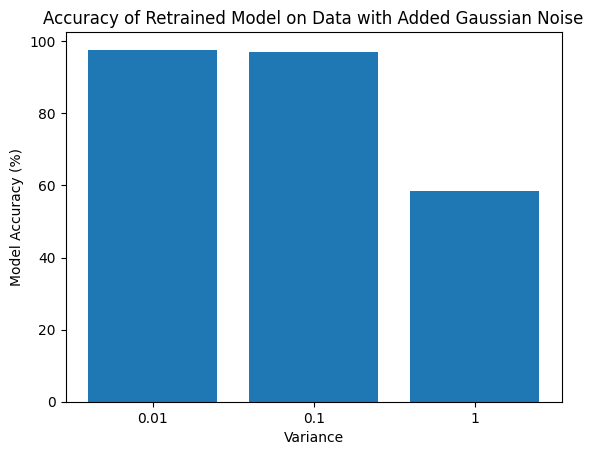

In [89]:
variances = ["0.01", "0.1", "1"]
gaussian_test_accuracies = []

for variance in variances:
    # create transformer with 0.01 var
    gaussian_transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x + math.sqrt(float(variance)) * torch.randn_like(x))
    ])

    test_dataset_gaussian = torchvision.datasets.MNIST(root='./data', train=False, transform=gaussian_transform, download=True)
    test_loader_gaussian = DataLoader(test_dataset_gaussian, batch_size=BATCH_SIZE, shuffle=False)

    gaussian_test_accuracies.append(get_accuracy(test_loader_gaussian, device, augmented_model))
    print(f"Accuracy with Gaussian Noise with Variance {variance}: {gaussian_test_accuracies[-1]:.2f}%")

# create bar plot
plt.bar(variances, gaussian_test_accuracies)

# Add labels and title
plt.xlabel("Variance")
plt.ylabel("Model Accuracy (%)")
plt.title("Accuracy of Retrained Model on Data with Added Gaussian Noise")

plt.show()
plt.close()